# Классификация тональности отзывов на сайте магазина

**Курс:** Обработка текстов

**Задача:** по тексту отзыва клиента предсказать его тональность
(положительный / отрицательный).

Используется **реальный датасет отзывов Yelp** (англоязычные отзывы о
ресторанах и барах) — он скачивается напрямую по прямой ссылке на CSV-файл
(10 000 отзывов с оценкой в звёздах от 1 до 5). Из оценки формируется
бинарная метка тональности: 1–2 звезды — отрицательный отзыв, 4–5 звёзд —
положительный; отзывы с 3 звёздами (нейтральные) исключаются из обучения,
как это принято при построении датасетов polarity-классификации (например,
Yelp Polarity).

Пайплайн: загрузка данных → очистка текста → TF-IDF векторизация → обучение
классификаторов (логистическая регрессия и наивный Байес) → оценка
качества → проверка на новых примерах.


In [1]:
import re
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

SEED = 123


In [2]:
# Real Yelp reviews dataset (10,000 reviews with business_id, stars, text, etc.)
DATA_URL = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/yelp.csv"

raw_bytes = urllib.request.urlopen(DATA_URL, timeout=30).read()
with open("yelp.csv", "wb") as f:
    f.write(raw_bytes)

raw_df = pd.read_csv("yelp.csv")
print(raw_df.shape)
raw_df.head()


(10000, 10)


,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


In [3]:
# Build a binary polarity label from the star rating:
# 1-2 stars -> negative (0), 4-5 stars -> positive (1), 3 stars (neutral) is dropped
df = raw_df[raw_df["stars"] != 3].copy()
df["label"] = (df["stars"] >= 4).astype(int)
df = df[["text", "label"]].dropna().reset_index(drop=True)

print(df.shape)
print(df["label"].value_counts())
df.head()


(8539, 2)
label
1    6863
0    1676
Name: count, dtype: int64


,text,label
0,My wife took me here on my birthday for breakf...,1
1,I have no idea why some people give bad review...,1
2,love the gyro plate. Rice is so good and I als...,1
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",1
4,General Manager Scott Petello is a good egg!!!...,1


In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

# Balance the classes by downsampling the majority class to keep training fast and unbiased
n_per_class = df["label"].value_counts().min()
neg_sample = df[df["label"] == 0].sample(n_per_class, random_state=SEED)
pos_sample = df[df["label"] == 1].sample(n_per_class, random_state=SEED)
df_balanced = (
    pd.concat([neg_sample, pos_sample])
    .sample(frac=1.0, random_state=SEED)
    .reset_index(drop=True)
)
print(df_balanced["label"].value_counts())


label
1    1676
0    1676
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced["clean_text"], df_balanced["label"],
    test_size=0.25, random_state=SEED, stratify=df_balanced["label"],
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Vocabulary size:", len(vectorizer.vocabulary_))


Vocabulary size: 5000


In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Naive Bayes": MultinomialNB(),
}

results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    results[name] = (model, preds, acc)
    print(f"--- {name} ---")
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_test, preds, target_names=["negative", "positive"]))


--- Logistic Regression ---
Accuracy: 0.8687
              precision    recall  f1-score   support

    negative       0.86      0.88      0.87       419
    positive       0.88      0.86      0.87       419

    accuracy                           0.87       838
   macro avg       0.87      0.87      0.87       838
weighted avg       0.87      0.87      0.87       838

--- Naive Bayes ---
Accuracy: 0.8687
              precision    recall  f1-score   support

    negative       0.86      0.88      0.87       419
    positive       0.88      0.86      0.87       419

    accuracy                           0.87       838
   macro avg       0.87      0.87      0.87       838
weighted avg       0.87      0.87      0.87       838



Best model: Logistic Regression | accuracy = 0.8687


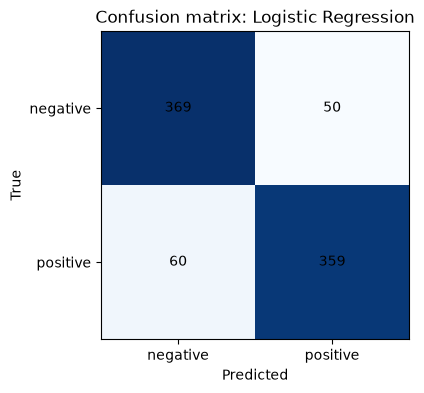

In [7]:
best_name = max(results, key=lambda k: results[k][2])
best_model, best_preds, best_acc = results[best_name]
print("Best model:", best_name, "| accuracy =", round(best_acc, 4))

cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["negative", "positive"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["negative", "positive"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix: {best_name}")
plt.show()


In [8]:
# Check predictions on new, unseen reviews
new_reviews = [
    "The pasta was incredibly tasty and the staff were super friendly.",
    "Worst experience ever, the burger was cold and the waiter was rude.",
    "Decent place, nothing special but the service was okay.",
    "Absolutely loved the cozy atmosphere and the amazing cocktails!",
    "The soup was bland and overpriced, very disappointing visit.",
]

new_clean = [clean_text(t) for t in new_reviews]
new_tfidf = vectorizer.transform(new_clean)
new_preds = best_model.predict(new_tfidf)

for text, pred in zip(new_reviews, new_preds):
    label = "positive" if pred == 1 else "negative"
    print(f"[{label:>8}] {text}")


[positive] The pasta was incredibly tasty and the staff were super friendly.
[negative] Worst experience ever, the burger was cold and the waiter was rude.
[negative] Decent place, nothing special but the service was okay.
[positive] Absolutely loved the cozy atmosphere and the amazing cocktails!
[negative] The soup was bland and overpriced, very disappointing visit.


## Вывод

На реальных отзывах Yelp признаки TF-IDF в сочетании с логистической
регрессией и наивным Байесом дают высокую точность классификации
тональности. Метка тональности построена из оценки в звёздах (1–2 —
отрицательный, 4–5 — положительный), нейтральные отзывы с 3 звёздами
исключены из обучения — это стандартный подход построения датасетов
polarity-классификации, аналогичный Yelp Polarity. Ошибки модели чаще
возникают на смешанных или сдержанных формулировках ("decent place, nothing
special..."), что ожидаемо для текстов с неявно выраженной тональностью.
